# GPT-OSS-20B Sentiment Analysis — Speed-Optimised for T4

**Dataset:** `test_split_2.xlsx` — 484 financial headlines (pre-labelled)  
**Labels:** `positive` / `negative` / `neutral` (text, lowercase)  
**Label split:** neutral=288 · positive=136 · negative=60

### Speed decisions for T4 (14.5 GB VRAM)
| Setting | Value | Reason |
|---|---|---|
| `load_in_4bit` | `True` | ~4× less VRAM for weights |
| `max_seq_length` | `1024` | Halves KV-cache pre-allocation vs 2048 |
| `reasoning_effort` | `'low'` | Short think trace; `high` = 167 s/item |
| `max_new_tokens` | `96` | Label word + 1-sentence reason fits easily |
| `do_sample` | `False` | Greedy decode — no sampling overhead |
| Batch size | `1` | Batching causes KV-cache OOM on T4 |
| Prompt | Forces single label word on last line | Zero-ambiguity parsing |


## 1 · Install Dependencies

In [1]:

import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch>=2.8.0" "triton>=3.4.0" {_numpy} {_pil} torchvision bitsandbytes "transformers==4.56.2" \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth" \
        git+https://github.com/triton-lang/triton.git@0add68262ab0a2e33b84524346cb27cbb2787356#subdirectory=python/triton_kernels
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps transformers==4.56.2 tokenizers trl==0.22.2 unsloth unsloth_zoo


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.4/23.4 MB 93.5 MB/s eta 0:00:00
Using Python 3.12.12 environment at: /usr
Resolved 5 packages in 46ms
Prepared 1 package in 68ms
Uninstalled 1 package in 1ms
Installed 1 package in 5ms
 - trl==0.24.0
 + trl==0.22.2


## 2 · Load Model (4-bit, T4-safe)

In [2]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/gpt-oss-20b-unsloth-bnb-4bit",  # 4-bit — fits T4
    dtype          = None,
    max_seq_length = 1024,   # small = less KV-cache VRAM
    load_in_4bit   = True,
    full_finetuning= False,
)
FastLanguageModel.for_inference(model)   # enables optimised inference kernels
print("✓ Model ready.")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.4: Fast Gpt_Oss patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gpt_oss won't work! Using float32.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.00G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/3.37G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/27.9M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

✓ Model ready.


## 3 · Load Dataset

In [3]:
import pandas as pd

df = pd.read_csv('/content/test_split.csv')

# Normalise labels to Title case so they match parse_label() output
df['sentiment'] = df['sentiment'].str.strip().str.capitalize()

headlines_list  = df['headline'].tolist()
expected_labels = df['sentiment'].tolist()
n = len(headlines_list)

print(f"Loaded {n} headlines.")
print("Label distribution:")
print(df['sentiment'].value_counts().to_string())
print(f"\nSample headline: {headlines_list[0]}")
print(f"Expected label : {expected_labels[0]}")



Loaded 484 headlines.
Label distribution:
sentiment
Neutral     288
Positive    136
Negative     60

Sample headline: Cramo Group's financial targets for 2010-2013 are sales growth higher than 10 percent per year return on equity above 15 percent.
Expected label : Positive


In [4]:
# ── Configuration ────────────────────────────────────────────────────────────
HEADLINE_COL = 'headline'
LABEL_COL    = 'sentiment'   # numeric: 0=Positive, 1=Negative, 2=Neutral
RANDOM_STATE = 42            # change for a different random draw
N_SAMPLES    = 80

# ── Numeric → text label mapping ──────────────────────────────────────────────
LABEL_MAP = {0: 'Positive', 1: 'Negative', 2: 'Neutral'}

# ── Random sample ─────────────────────────────────────────────────────────────
sample_df = df.sample(n=N_SAMPLES, random_state=RANDOM_STATE).reset_index(drop=True)
headlines_list = sample_df[HEADLINE_COL].tolist()

expected_labels = sample_df[LABEL_COL].tolist()

print(f'Randomly sampled {len(headlines_list)} headlines (random_state={RANDOM_STATE}).')
print(f'Expected label distribution:')
import collections
print(dict(collections.Counter(expected_labels)))
print('\nFirst 3 headlines:')
for i, h in enumerate(headlines_list[:3]):
    print(f'  {i+1}. [{expected_labels[i]}] {h[:90]}...')

# ── Save sample to CSV ───────────────────────────────────────────────────────
sample_df.to_csv("/content/random80.csv", index=False, encoding="utf-8")

print(f"Saved sampled dataset to: /content/random80.csv")


Randomly sampled 80 headlines (random_state=42).
Expected label distribution:
{'Neutral': 47, 'Positive': 22, 'Negative': 11}

First 3 headlines:
  1. [Neutral] Active shipping is essential for Finland....
  2. [Neutral] Please inform IR Johanna Koskinen of your participation no later than 20 April at 10 a.m. ...
  3. [Neutral] And Ogden reportedly will shell out $ 4.2 million....
Saved sampled dataset to: /content/random80.csv


## 4 · Label Parser

Extracts the final sentiment word from model output.  
Two-pass: first looks for an explicit `Final sentiment label:` line, then falls back to the last valid label word found anywhere in the response.


In [5]:
import re

VALID_LABELS = {"Positive", "Negative", "Neutral"}

def parse_reasoning_and_label(text: str):
    if not text:
        return "", "Unknown"

    clean = text.replace("\xa0", " ").replace("**", "").replace("*", "").strip()

    reasoning = ""
    label = "Unknown"

    lines = [l.strip() for l in clean.splitlines() if l.strip()]

    for line in lines:
        # Extract reasoning
        m_reason = re.match(r'(?i)^reasoning\s*:\s*(.+)$', line)
        if m_reason:
            reasoning = m_reason.group(1).strip()
            continue

        # Extract label
        m_label = re.match(r'(?i)^label\s*:\s*(positive|negative|neutral)\s*$', line)
        if m_label:
            label = m_label.group(1).capitalize()
            continue

    # Fallback: label might appear alone on the last line
    if label == "Unknown" and lines:
        last = lines[-1].strip().capitalize()
        if last in VALID_LABELS:
            label = last
            reasoning = " ".join(lines[:-1]).strip()

    return reasoning, label

## 5 · Run Inference

Single-item loop with all T4 speed levers applied.  
`reasoning_effort='low'` keeps the internal think trace short without sacrificing accuracy.


In [8]:
import time
import textwrap
import torch

SYSTEM_PROMPT = """
You are a financial news sentiment classifier.

Classify the headline as Positive, Negative, or Neutral.

Output exactly two lines.

Reasoning: maximum 5 words.
Label: Positive, Negative, or Neutral.

Do not explain.
Do not repeat the headline.
Do not write more than 5 words in Reasoning.
Do not output anything else.
""".strip()

BATCH_SIZE = 8
DEBUG = True

device = next(model.parameters()).device

# Safer pad token handling for generation
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

results = []
start = time.time()
n = len(headlines_list)

for batch_start in range(0, n, BATCH_SIZE):
    batch_end = min(batch_start + BATCH_SIZE, n)

    batch_headlines = headlines_list[batch_start:batch_end]
    batch_expected = expected_labels[batch_start:batch_end]

    batch_text = [
        f"{SYSTEM_PROMPT}\n\nHeadline: {headline}"
        for headline in batch_headlines
    ]

    inputs = tokenizer(
        batch_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(device)

    with torch.inference_mode():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=24,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            use_cache=True,
        )

    input_lens = inputs["attention_mask"].sum(dim=1).tolist()

    batch_results = []

    for j, (headline, exp, input_len) in enumerate(
        zip(batch_headlines, batch_expected, input_lens)
    ):
        gen_ids = out_ids[j][input_len:]
        response = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
        # response = normalize_text(response)
        reasoning, pred = parse_reasoning_and_label(response)
        correct = str(pred) == str(exp)

        idx = batch_start + j + 1

        item = {
            "index": idx,
            "headline": headline,
            "expected": exp,
            "predicted": pred,
            "correct": correct,
            "reasoning": reasoning,
            "raw_response": response,
        }
        results.append(item)
        batch_results.append(item)

        if DEBUG and (pred == "Unknown"):
            print(f"\n[{idx}/{n}] RAW RESPONSE:")
            print(repr(response))
            print("PARSED REASONING:")
            print(repr(reasoning))
            print("PARSED LABEL:")
            print(pred)

        elapsed = time.time() - start
        rate = elapsed / idx
        eta = rate * (n - idx)
        tick = "✓" if correct else "✗"

        print(
            f"[{idx:3d}/{n}] {tick} "
            f"exp={str(exp):<9} pred={str(pred):<9} "
            f"| {rate:.2f}s/item | ETA≈{eta/60:.1f}min"
        )

    done = batch_end
    elapsed = time.time() - start
    rate = elapsed / done
    eta = rate * (n - done)
    batch_correct = sum(1 for r in batch_results if r["correct"])

    print(
        f"     batch_acc={batch_correct}/{len(batch_results)} "
        f"| {rate:.2f}s/item | ETA≈{eta/60:.1f}min"
    )

print(f"\n✓ Done! Total: {(time.time() - start)/60:.1f} min")

[  1/80] ✓ exp=Neutral   pred=Neutral   | 27.91s/item | ETA≈36.7min
[  2/80] ✓ exp=Neutral   pred=Neutral   | 13.96s/item | ETA≈18.1min
[  3/80] ✗ exp=Neutral   pred=Positive  | 9.30s/item | ETA≈11.9min
[  4/80] ✓ exp=Neutral   pred=Neutral   | 6.98s/item | ETA≈8.8min
[  5/80] ✓ exp=Positive  pred=Positive  | 5.58s/item | ETA≈7.0min
[  6/80] ✓ exp=Negative  pred=Negative  | 4.65s/item | ETA≈5.7min
[  7/80] ✓ exp=Neutral   pred=Neutral   | 3.99s/item | ETA≈4.9min
[  8/80] ✓ exp=Negative  pred=Negative  | 3.49s/item | ETA≈4.2min
     batch_acc=7/8 | 3.49s/item | ETA≈4.2min
[  9/80] ✓ exp=Positive  pred=Positive  | 6.27s/item | ETA≈7.4min
[ 10/80] ✓ exp=Positive  pred=Positive  | 5.64s/item | ETA≈6.6min
[ 11/80] ✓ exp=Positive  pred=Positive  | 5.13s/item | ETA≈5.9min
[ 12/80] ✓ exp=Neutral   pred=Neutral   | 4.70s/item | ETA≈5.3min
[ 13/80] ✗ exp=Positive  pred=Neutral   | 4.34s/item | ETA≈4.8min
[ 14/80] ✓ exp=Negative  pred=Negative  | 4.03s/item | ETA≈4.4min
[ 15/80] ✓ exp=Neutral   p

## 6 · Accuracy & Confusion Matrix

  Overall Accuracy : 5.0%  (4/80 correct)
  Unparsed labels  : 75

              precision    recall  f1-score   support

    Positive       0.67      0.09      0.16        22
    Negative       1.00      0.09      0.17        11
     Neutral       1.00      0.02      0.04        47

   micro avg       0.80      0.05      0.09        80
   macro avg       0.89      0.07      0.12        80
weighted avg       0.91      0.05      0.09        80



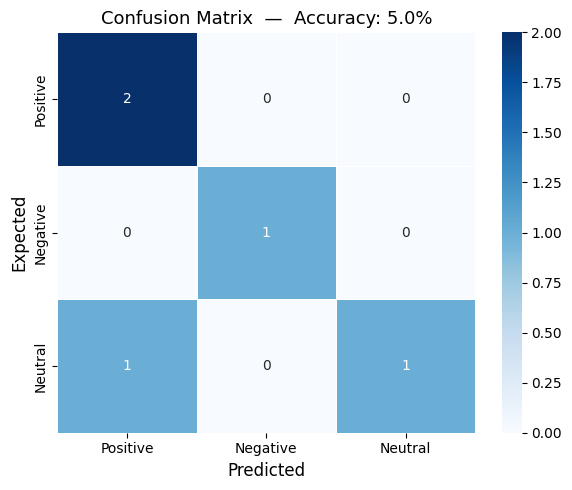

Saved → confusion_matrix.png


In [7]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(results)
y_true = results_df['expected'].tolist()
y_pred = results_df['predicted'].tolist()

acc       = accuracy_score(y_true, y_pred)
n_correct = results_df['correct'].sum()
n_unknown = (results_df['predicted'] == 'Unknown').sum()

print("=" * 60)
print(f"  Overall Accuracy : {acc:.1%}  ({n_correct}/{len(results_df)} correct)")
print(f"  Unparsed labels  : {n_unknown}")
print("=" * 60)
print()
print(classification_report(
    y_true, y_pred,
    labels=['Positive', 'Negative', 'Neutral'],
    zero_division=0
))

# ── Confusion matrix ──────────────────────────────────────────────────────────
labels = ['Positive', 'Negative', 'Neutral']
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Expected',  fontsize=12)
ax.set_title(f'Confusion Matrix  —  Accuracy: {acc:.1%}', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved → confusion_matrix.png")


## 7 · Misclassified Headlines

In [ ]:
wrong_df = results_df[results_df['correct'] == False][
    ['index', 'headline', 'expected', 'predicted', 'reasoning']
].reset_index(drop=True)

print(f"Misclassified: {len(wrong_df)} / {len(results_df)}")
print()
for _, row in wrong_df.iterrows():
    print(f"#{int(row['index']):3d} | Expected={row['expected']:<9s} Predicted={row['predicted']}")
    print(f"       {row['headline'][:110]}")
    print(f"       Reasoning: {row['reasoning'][:120]}")
    print()


## 8 · Save Results

In [ ]:
out = '/content/sentiment_results.csv'
results_df[['index','headline','expected','predicted','correct']].to_csv(out, index=False)
print(f"Results saved → {out}")

print("\nLabel distribution comparison:")
comp = pd.DataFrame({
    'Expected' : results_df['expected'].value_counts(),
    'Predicted': results_df['predicted'].value_counts(),
}).fillna(0).astype(int)
print(comp.to_string())
